In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.datasets import make_classification
X,Y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,n_redundant=0,n_classes=2)

In [20]:
X

array([[ 1.10330072,  1.28120284],
       [-1.75997248, -0.22850805],
       [ 1.85322118,  2.51486973],
       ...,
       [-2.5160214 ,  0.54576527],
       [ 0.26640375, -0.26757685],
       [-1.14227896, -1.17323269]], shape=(1000, 2))

In [21]:
x0=pd.DataFrame(X)[0]
x1=pd.DataFrame(X)[1]

<Axes: xlabel='0', ylabel='1'>

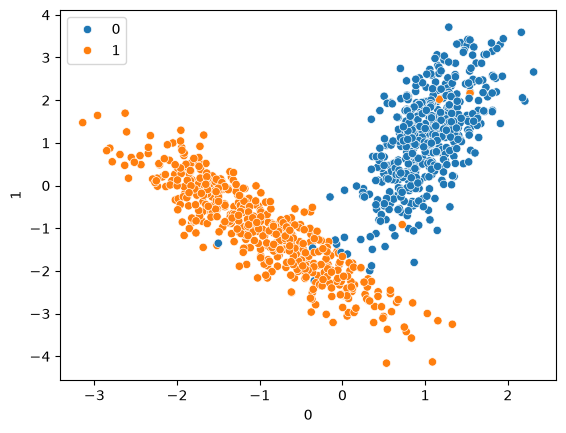

In [22]:
sns.scatterplot(x=x0,y=x1,hue=Y)

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=10)
from sklearn.svm import SVC
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       149
           1       0.98      0.99      0.99       151

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

[[146   3]
 [  1 150]]


In [24]:
W,V=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=2,n_redundant=0,n_classes=2)

<Axes: xlabel='0', ylabel='1'>

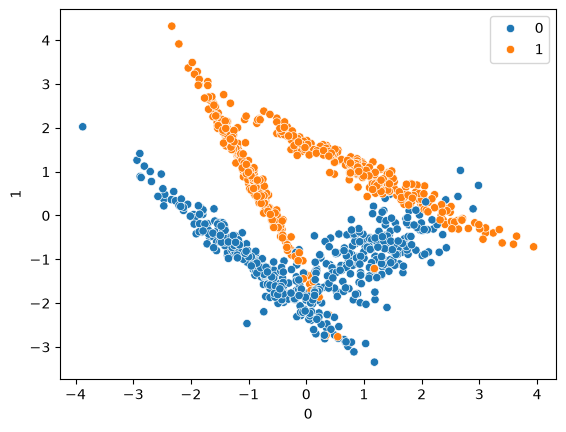

In [25]:
sns.scatterplot(x=pd.DataFrame(W)[0],y=pd.DataFrame(W)[1],hue=V)

In [26]:
W_train,W_test,V_train,V_test=train_test_split(W,V,test_size=0.3,random_state=10)
model=SVC(kernel='rbf')
model.fit(W_train,V_train)
y_pred1=model.predict(W_test)
print(classification_report(V_test,y_pred1))
print(confusion_matrix(V_test,y_pred1))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       150
           1       0.97      0.97      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

[[145   5]
 [  4 146]]


In [27]:
model1=SVC(kernel='poly')
model1.fit(W_train,V_train)
y_pred2=model1.predict(W_test)
print(classification_report(V_test,y_pred2))
print(confusion_matrix(V_test,y_pred2))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       150
           1       0.91      0.89      0.90       150

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[137  13]
 [ 16 134]]


In [28]:
model2=SVC(kernel='linear')
model2.fit(W_train,V_train)
y_pred3=model2.predict(W_test)
print(classification_report(V_test,y_pred3))
print(confusion_matrix(V_test,y_pred3))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       150
           1       0.90      0.91      0.91       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

[[135  15]
 [ 13 137]]


In [29]:
model3=SVC(kernel='sigmoid')
model3.fit(W_train,V_train)
y_pred4=model3.predict(W_test)
print(classification_report(V_test,y_pred4))
print(confusion_matrix(V_test,y_pred4))

              precision    recall  f1-score   support

           0       0.80      0.72      0.76       150
           1       0.75      0.82      0.78       150

    accuracy                           0.77       300
   macro avg       0.77      0.77      0.77       300
weighted avg       0.77      0.77      0.77       300

[[108  42]
 [ 27 123]]


In [30]:
params_grid={
    'C':[0.1,1.0,10,100,1000],
    'gamma':[0.001, 0.01, 0.1, 1, 10, 100],
    'kernel':['rbf']
}


In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=params_grid,cv=5,verbose=3,refit=True,)

In [32]:
grid.fit(W_train,V_train)
y_pred6=grid.predict(W_test)
print(classification_report(V_test,y_pred6))
print(confusion_matrix(V_test,y_pred6))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.814 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.857 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.914 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.850 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.850 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.886 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.907 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.871 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.843 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

In [35]:
grid.best_params_

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}